In [ ]:
#
^

In [37]:
!pip install folium gpxpy geopy scikit-learn matplotlib seaborn pandas

#foookingg dependenciesss

In [38]:
import os
import folium
import gpxpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from geopy.distance import geodesic
from folium.plugins import HeatMap
import numpy as np
from sklearn.cluster import DBSCAN

In [40]:
working_project = "C:\\Users\\alex\\PycharmProjects\\transDinaricaRoute\\assets\\"

gpx_files = [
    'TransDinarica_-_2024.gpx',
    'TransDinarica_-_Dan_1.gpx',
    'TransDinarica_-_Dan_2.gpx',
    'TransDinarica_-_Dan_3.gpx',
    'Transdinarica_-_predlog_1_(onako_grubo).gpx',
    'Transdinarica.gpx'
]



In [47]:

routes = []

for file in gpx_files:
    file_path = os.path.join(working_project, file)
    with open(file_path, 'r') as gpx_file:
        gpx = gpxpy.parse(gpx_file)
        for track in gpx.tracks:
            for segment in track.segments:
                points = [(point.latitude, point.longitude, point.elevation) for point in segment.points]
                routes.append({'file': file, 'points': points})


In [41]:
def route_distance(points):
    distance = 0.0
    for i in range(1, len(points)):
        distance += geodesic(points[i-1], points[i]).km
    return distance

route_distances = []

for route in routes:
    dist = route_distance(route['points'])
    route_distances.append({
        'file': route['file'],
        'distance_km': dist
    })

distances_df = pd.DataFrame(route_distances)
distances_df


,file,distance_km
0,TransDinarica_-_2024.gpx,319.550734
1,TransDinarica_-_Dan_1.gpx,118.810217
2,TransDinarica_-_Dan_2.gpx,92.716652
3,TransDinarica_-_Dan_3.gpx,108.023055
4,Transdinarica_-_predlog_1_(onako_grubo).gpx,501.570796
5,Transdinarica.gpx,276.272859


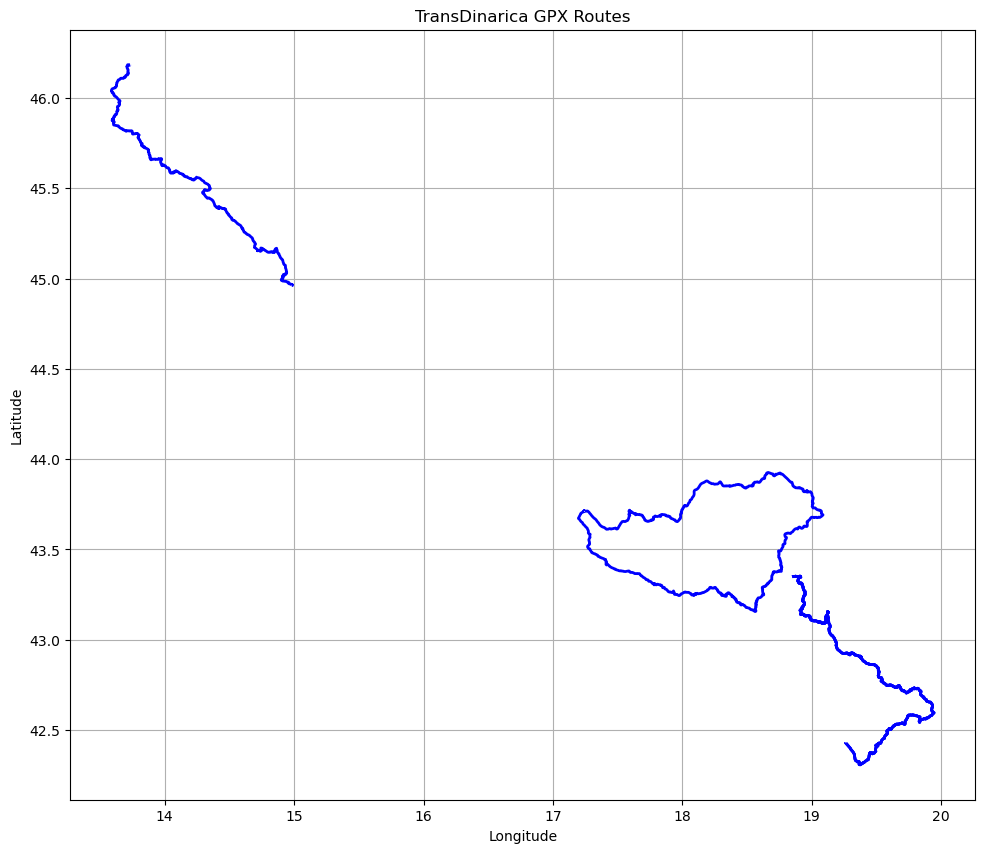

In [26]:

gdf.plot(figsize=(12, 10), color='blue', linewidth=2)
plt.title('TransDinarica GPX Routes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()


In [27]:

gdf['length_deg'] = gdf.length

gdf[['length_deg']]


C:\Users\alex\AppData\Local\Temp\ipykernel_6764\2812186170.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['length_deg'] = gdf.length


,length_deg
0,3.416844
1,1.261218
2,1.001124
3,1.154494
4,5.493796
5,3.416844
6,3.028684


In [28]:
gdf_utm = gdf.to_crs(epsg=32633)
gdf_utm['length_meters'] = gdf_utm.length
gdf_utm['length_km'] = gdf_utm['length_meters'] / 1000

gdf_utm[['length_km']]


,length_km
0,319.936681
1,118.922015
2,92.844969
3,108.168886
4,501.788470
5,319.936681
6,276.179399


In [45]:
all_points = []
for route in routes:
    all_points.extend(route['points'])

m = folium.Map(location=[44, 17], zoom_start=6)

HeatMap(all_points, radius=8).add_to(m)

m.save('transdinarica_heatmap.html')

file_path = "C:'\Users\\alex\\PycharmProjects\\transDinaricaRoute\\transdinaricax_heatmap.html"
from IPython.display import display, HTML
display(HTML(f'<a href="file:///{file_path}" target="_blank">Open Heatmap</a>'))


SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 3-4: truncated \UXXXXXXXX escape (1947152918.py, line 14)

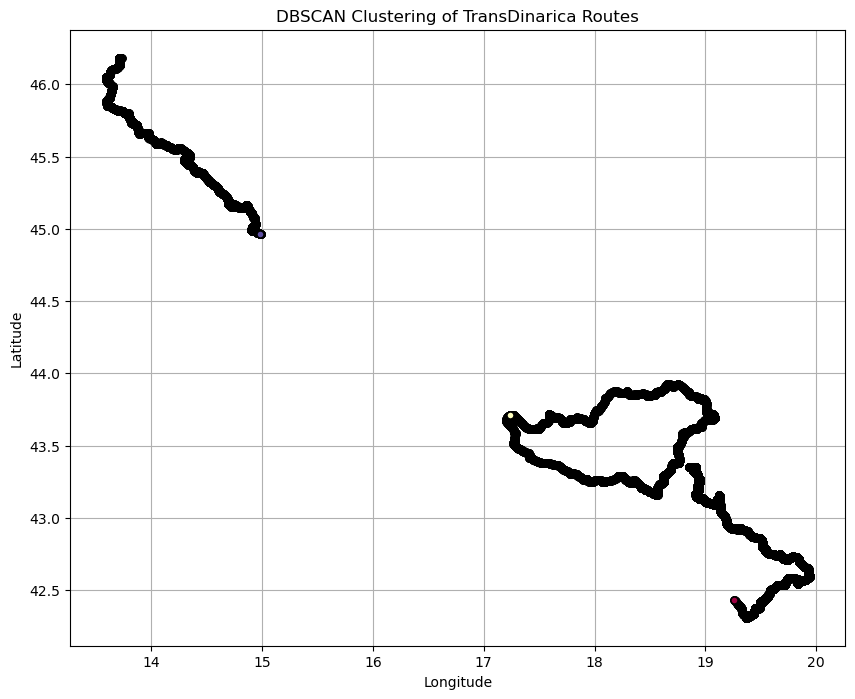

In [46]:
from sklearn.cluster import DBSCAN

points_array = np.array(all_points)

db = DBSCAN(eps=0.05, min_samples=10).fit(points_array)

labels = db.labels_

# Plot
plt.figure(figsize=(10,8))
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:

        col = [0, 0, 0, 1]
    class_member_mask = (labels == k)
    xy = points_array[class_member_mask]
    plt.plot(xy[:, 1], xy[:, 0], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=5)

plt.title('DBSCAN Clustering of TransDinarica Routes')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()


In [48]:
def elevation_stats(points):
    gain = 0.0
    loss = 0.0
    for i in range(1, len(points)):
        delta = points[i][2] - points[i-1][2]
        if delta > 0:
            gain += delta
        else:
            loss += abs(delta)
    return gain, loss

full_stats = []

for route in routes:
    dist = route_distance([(lat, lon) for lat, lon, ele in route['points']])
    gain, loss = elevation_stats(route['points'])
    elevations = [ele for lat, lon, ele in route['points']]
    max_elevation = max(elevations)
    min_elevation = min(elevations)

    full_stats.append({
        'file': route['file'],
        'distance_km': dist,
        'elevation_gain_m': gain,
        'elevation_loss_m': loss,
        'max_elevation_m': max_elevation,
        'min_elevation_m': min_elevation
    })

full_stats_df = pd.DataFrame(full_stats)
full_stats_df


,file,distance_km,elevation_gain_m,elevation_loss_m,max_elevation_m,min_elevation_m
0,TransDinarica_-_2024.gpx,319.550734,10174.3,10605.8,1905.6,7.7
1,TransDinarica_-_Dan_1.gpx,118.810217,4475.9,3290.8,1905.6,475.5
2,TransDinarica_-_Dan_2.gpx,92.716652,2732.4,3443.3,1749.5,750.7
3,TransDinarica_-_Dan_3.gpx,108.023055,2965.8,3871.5,1358.7,7.7
4,Transdinarica_-_predlog_1_(onako_grubo).gpx,501.570796,10110.8,10107.8,1295.0,41.0
5,Transdinarica.gpx,276.272859,6519.0,6158.9,797.0,1.5


In [49]:
def elevation_stats(points):
    gain = 0.0
    loss = 0.0
    for i in range(1, len(points)):
        delta = points[i][2] - points[i-1][2]
        if delta > 0:
            gain += delta
        else:
            loss += abs(delta)
    return gain, loss
full_stats = []

for route in routes:
    dist = route_distance([(lat, lon) for lat, lon, ele in route['points']])
    gain, loss = elevation_stats(route['points'])
    elevations = [ele for lat, lon, ele in route['points']]
    max_elevation = max(elevations)
    min_elevation = min(elevations)

    full_stats.append({
        'file': route['file'],
        'distance_km': dist,
        'elevation_gain_m': gain,
        'elevation_loss_m': loss,
        'max_elevation_m': max_elevation,
        'min_elevation_m': min_elevation
    })

full_stats_df = pd.DataFrame(full_stats)
full_stats_df


,file,distance_km,elevation_gain_m,elevation_loss_m,max_elevation_m,min_elevation_m
0,TransDinarica_-_2024.gpx,319.550734,10174.3,10605.8,1905.6,7.7
1,TransDinarica_-_Dan_1.gpx,118.810217,4475.9,3290.8,1905.6,475.5
2,TransDinarica_-_Dan_2.gpx,92.716652,2732.4,3443.3,1749.5,750.7
3,TransDinarica_-_Dan_3.gpx,108.023055,2965.8,3871.5,1358.7,7.7
4,Transdinarica_-_predlog_1_(onako_grubo).gpx,501.570796,10110.8,10107.8,1295.0,41.0
5,Transdinarica.gpx,276.272859,6519.0,6158.9,797.0,1.5


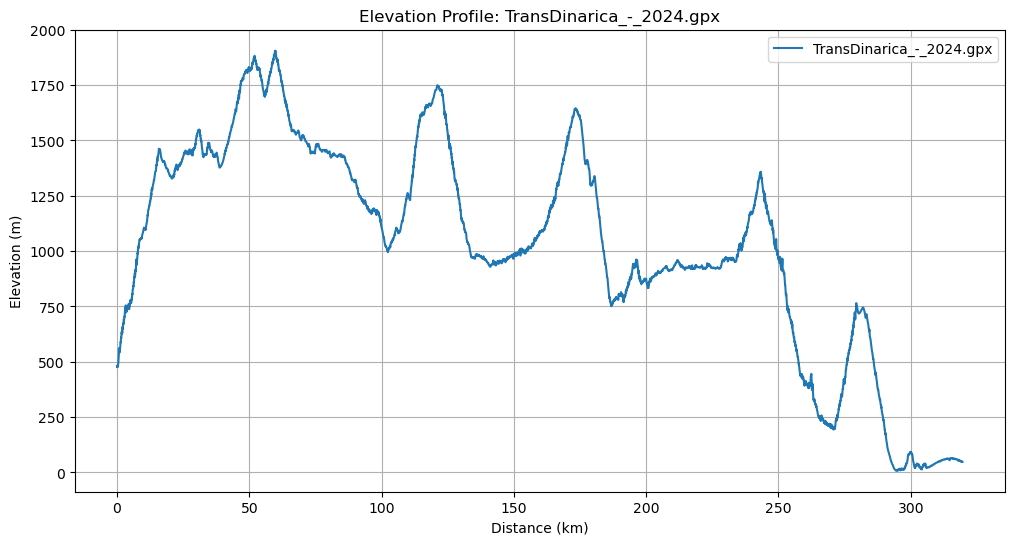

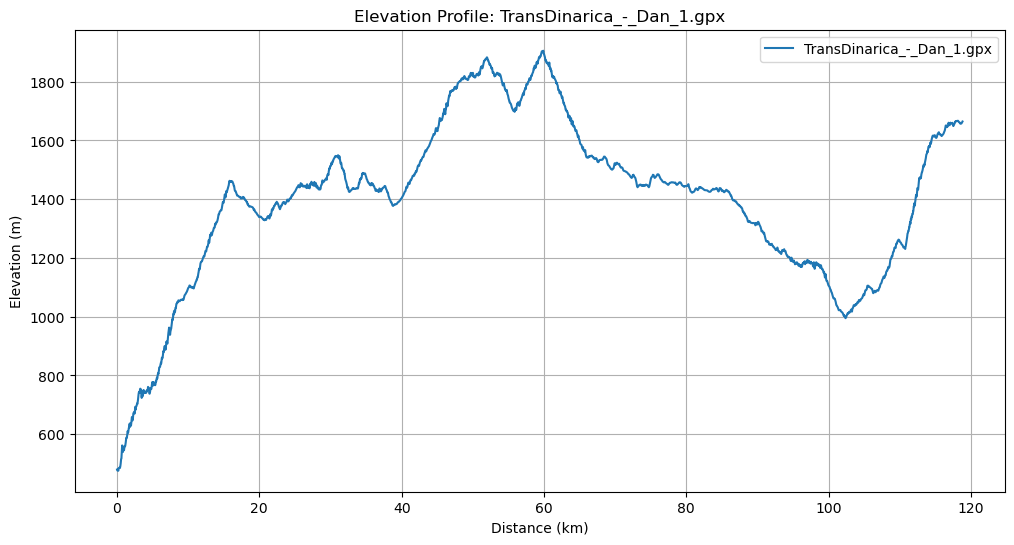

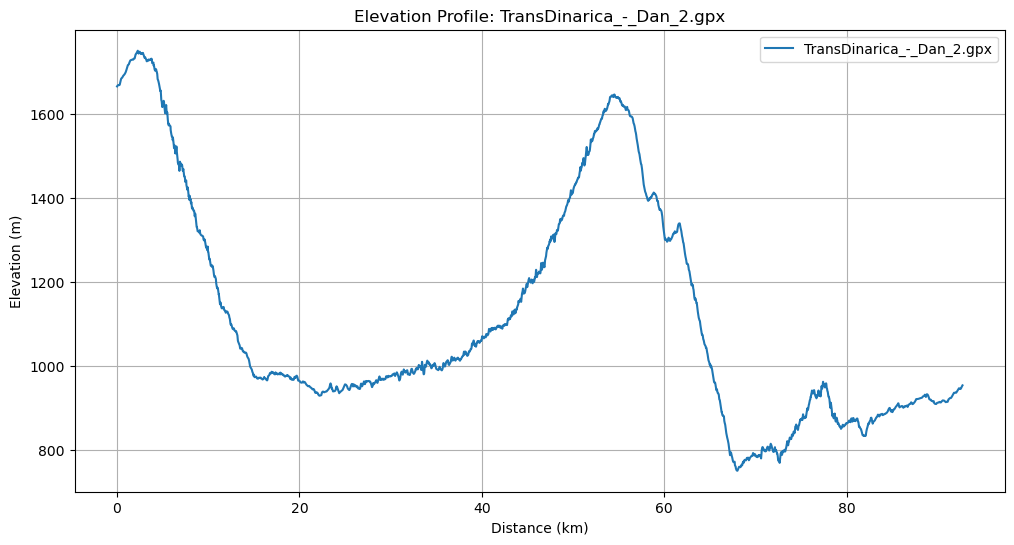

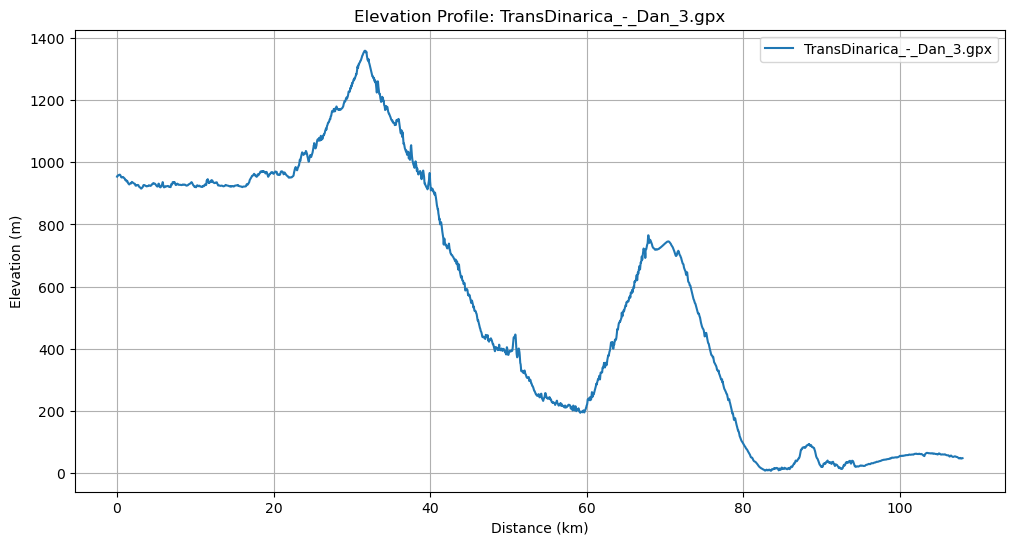

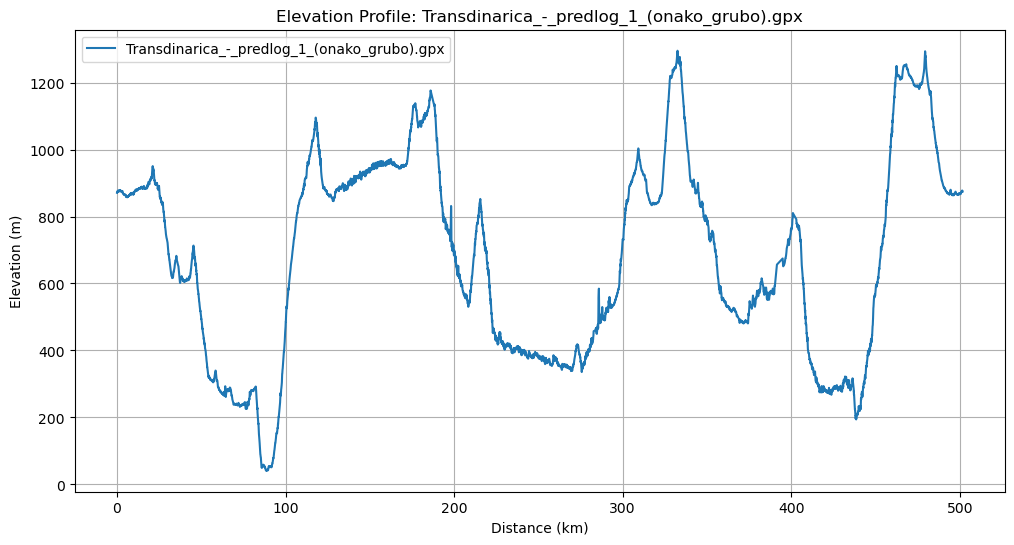

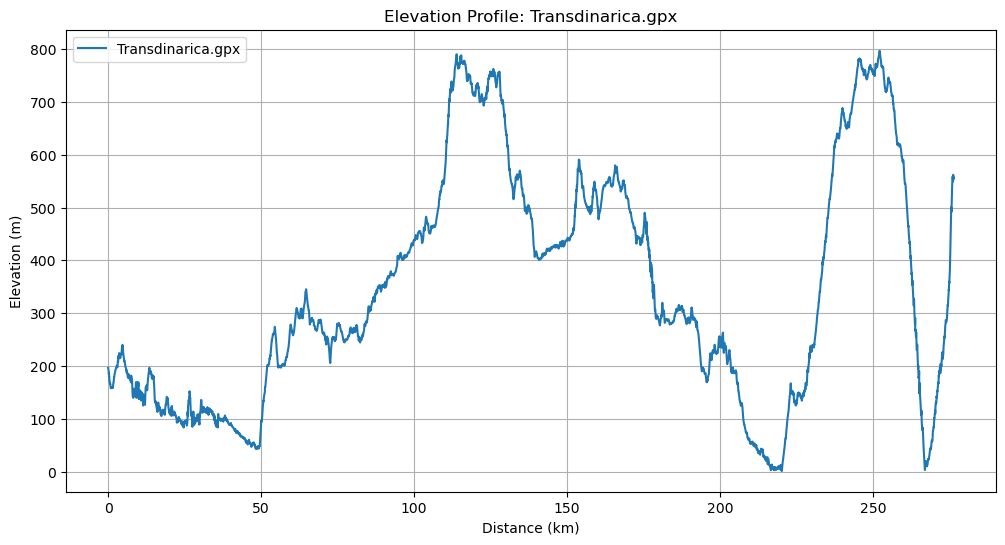

In [50]:
for route in routes:
    points = route['points']
    dists = [0]
    total_dist = 0

    for i in range(1, len(points)):
        step = geodesic((points[i-1][0], points[i-1][1]), (points[i][0], points[i][1])).km
        total_dist += step
        dists.append(total_dist)

    elevations = [ele for lat, lon, ele in points]

    plt.figure(figsize=(12,6))
    plt.plot(dists, elevations, label=route['file'])
    plt.title(f"Elevation Profile: {route['file']}")
    plt.xlabel('Distance (km)')
    plt.ylabel('Elevation (m)')
    plt.grid(True)
    plt.legend()
    plt.show()


In [51]:
def steepest_slope(points):
    max_slope = -float('inf')
    for i in range(1, len(points)):
        dist_km = geodesic((points[i-1][0], points[i-1][1]), (points[i][0], points[i][1])).km
        dist_m = dist_km * 1000  # meters
        elevation_change = points[i][2] - points[i-1][2]

        if dist_m > 0:
            slope = (elevation_change / dist_m) * 100  # % slope
            if slope > max_slope:
                max_slope = slope
    return max_slope

steepness = []

for route in routes:
    slope = steepest_slope(route['points'])
    steepness.append({
        'file': route['file'],
        'max_slope_percent': slope
    })

steepness_df = pd.DataFrame(steepness)
steepness_df


,file,max_slope_percent
0,TransDinarica_-_2024.gpx,106.230162
1,TransDinarica_-_Dan_1.gpx,76.529453
2,TransDinarica_-_Dan_2.gpx,43.389973
3,TransDinarica_-_Dan_3.gpx,106.230162
4,Transdinarica_-_predlog_1_(onako_grubo).gpx,71.544789
5,Transdinarica.gpx,86.949080


In [52]:

difficulty_index = []

for stat in full_stats:
    # Avoid division by zero
    if stat['distance_km'] > 0:
        index = (stat['elevation_gain_m'] / stat['distance_km']) * (100 / 1)  # meters per 100km
    else:
        index = 0
    difficulty_index.append({
        'file': stat['file'],
        'difficulty_index': index
    })

difficulty_index_df = pd.DataFrame(difficulty_index)
difficulty_index_df


,file,difficulty_index
0,TransDinarica_-_2024.gpx,3183.938864
1,TransDinarica_-_Dan_1.gpx,3767.268596
2,TransDinarica_-_Dan_2.gpx,2947.043415
3,TransDinarica_-_Dan_3.gpx,2745.525022
4,Transdinarica_-_predlog_1_(onako_grubo).gpx,2015.827093
5,Transdinarica.gpx,2359.623750


In [53]:
def find_toughest_section(points, window_km=1.0):
    elevations = [ele for lat, lon, ele in points]
    distances = [0.0]
    total_dist = 0.0

    for i in range(1, len(points)):
        step = geodesic((points[i-1][0], points[i-1][1]), (points[i][0], points[i][1])).km
        total_dist += step
        distances.append(total_dist)

    max_gain = -float('inf')
    best_start_idx = 0
    best_end_idx = 0

    for i in range(len(points)):
        for j in range(i+1, len(points)):
            if distances[j] - distances[i] >= window_km:
                gain = elevations[j] - elevations[i]
                if gain > max_gain:
                    max_gain = gain
                    best_start_idx = i
                    best_end_idx = j
                break  # move starting index

    return max_gain, points[best_start_idx], points[best_end_idx]

toughest_sections = []

for route in routes:
    gain, start_point, end_point = find_toughest_section(route['points'], window_km=1.0)  # 1 km toughest
    toughest_sections.append({
        'file': route['file'],
        'gain_m': gain,
        'start_point': start_point,
        'end_point': end_point
    })

toughest_sections_df = pd.DataFrame(toughest_sections)
toughest_sections_df


,file,gain_m,start_point,end_point
0,TransDinarica_-_2024.gpx,130.6,"(42.91983, 19.29072, 1339.6)","(42.9206, 19.29612, 1470.2)"
1,TransDinarica_-_Dan_1.gpx,130.6,"(42.91983, 19.29072, 1339.6)","(42.9206, 19.29612, 1470.2)"
2,TransDinarica_-_Dan_2.gpx,78.8,"(42.74459, 19.67015, 1437.5)","(42.74304, 19.67812, 1516.3)"
3,TransDinarica_-_Dan_3.gpx,104.3,"(42.41411, 19.50022, 618.2)","(42.41351, 19.50325, 722.5)"
4,Transdinarica_-_predlog_1_(onako_grubo).gpx,126.4,"(43.73057, 19.00977, 458.2)","(43.73838, 19.00285, 584.6)"
5,Transdinarica.gpx,199.9,"(44.96577, 14.97909, 358.7)","(44.96273, 14.98698, 558.6)"
